### Importing Libraries

In [1]:
import  pandas as pd
import numpy as np

In [3]:
df = pd.read_excel("./Datasets/Real_estate_valuation.xlsx")

In [4]:
df.head()

,No,X1 transaction date,X2 house age,X3 distance to the nearest MRT station,X4 number of convenience stores,X5 latitude,X6 longitude,Y house price of unit area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


In [6]:
df.shape

(414, 8)

In [7]:
df = df.rename(columns={"X1 transaction date" : "transaction_date",
                        "X2 house age":"house_age",
                        "X3 distance to the nearest MRT station": "distance_to_mrt_station",
                        "X4 number of convenience stores": "no_of_convenience_stores",
                        "X5 latitude" : "latitude",
                        "X6 longitude" : "longitude",
                        "Y house price of unit area" : "Y_house_price_unit_area"})
df.head()

,No,transaction_date,house_age,distance_to_mrt_station,no_of_convenience_stores,latitude,longitude,Y_house_price_unit_area
0,1,2012.916667,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.916667,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583333,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500000,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833333,5.0,390.56840,5,24.97937,121.54245,43.1


## First we will Build of Two Vriables then Convert it to all variables
### We will Use Two Approaches
- First is Simple Approach W@X
- Second Is SkLearn Approach

### First Approach Setting Weights and Extracting Inputs and Outputs

In [8]:
# W.shape = (1, d), where d = number of features
# Prediction shape = (1, n), where n = number of samples
## W@X
X = df[["transaction_date","house_age","no_of_convenience_stores","distance_to_mrt_station","latitude","longitude"]].to_numpy().T
Y = df["Y_house_price_unit_area"].to_numpy().T
# No of columns will be equal to the no of rows in Input
W = np.random.randn(1,X.shape[0])
print(f"W vector is {W}")
print(f"shape of X = {X.shape} ")
print(f"shape of Y = {Y.shape} ")



W vector is [[-1.6356264  -0.68347822 -0.60793571 -0.6817502   0.02094858 -0.09617958]]
shape of X = (6, 414) 
shape of Y = (414,) 


## Normalizing our Data

In [9]:
# axis=1 is applied on columns horizontally
# First Approach
X_norm = (X - np.mean(X,axis = 1, keepdims= True))/ np.std(X, axis=1, keepdims= True)
Y_norm = (Y - np.mean(Y))/ np.std(Y)

### Loss Function MSE


In [10]:
def loss_func(Y, Y_hat):
    return (1/(2*len(Y)))*np.sum((Y - Y_hat)**2)


## Gradient Descent for Multiple Linear Regression

We are implementing Multiple Linear Regression using two different matrix orientations.

Both approaches are mathematically equivalent.
The main difference is the orientation of the input matrix $X$ and the weight matrix $W$.

---

# Approach 1 — Features × Samples

In the first approach:

- Rows represent **features**
- Columns represent **samples**

Therefore:

$$
X \in \mathbb{R}^{d \times n}
$$

$$
W \in \mathbb{R}^{1 \times d}
$$

where:

- $d$ = number of features
- $n$ = number of training samples

In our current dataset:

$$
X = (6 \times 414)
$$

$$
W = (1 \times 6)
$$

### Prediction

The prediction is calculated as:

$$
\hat{Y} = WX + b
$$

Shape calculation:

$$
(1 \times d)(d \times n)
=
(1 \times n)
$$

For our dataset:

$$
(1 \times 6)(6 \times 414)
=
(1 \times 414)
$$

Therefore, the model produces one prediction for every training sample.

### Error

The prediction error is:

$$
E = \hat{Y} - Y
$$

where:

$$
E \in \mathbb{R}^{1 \times n}
$$

### Gradient with Respect to Weights

For this matrix orientation:

$$
\frac{\partial J}{\partial W}
=
\frac{1}{n}
(\hat{Y}-Y)X^T
$$

Shape calculation:

$$
(1 \times n)(n \times d)
=
(1 \times d)
$$

For our dataset:

$$
(1 \times 414)(414 \times 6)
=
(1 \times 6)
$$

Therefore:

$$
dW \in \mathbb{R}^{1 \times d}
$$

which gives one gradient for every weight.

In NumPy:

```python
dw = ((Y_hat - Y) @ X.T) / n
```

In [11]:
def dEdw(Y,Y_hat,X):
    n = len(Y)
    return  (Y_hat - Y)@X.T/n
def dEdb(Y, Y_hat):
    n = len(Y)
    return  np.sum((Y_hat - Y))/n
b = 0
Y_hat = W@X +b

print(dEdw(Y,Y_hat, X))
print(dEdb(Y, Y_hat))
Y_hat

[[-8244746.32117663   -72848.31913948   -15273.41422543 -5509726.66907238
   -102252.97958047  -497722.10136875]]
-4095.4401626958597


array([[-3389.36277537, -3531.36619156, -3699.89962135, -3699.7633192 ,
        -3576.13710174, -4792.63843988, -3756.02522186, -3517.95930888,
        -7084.60257479, -4534.10304425, -3604.4654315 , -3375.67370112,
        -3651.04974102, -5003.19031089, -4110.08149382, -3725.12838058,
        -3507.4906271 , -3555.17122512, -3571.75577338, -3324.35947436,
        -4860.84047731, -3506.12248081, -4241.47749261, -3505.30388062,
        -3660.89556076, -4339.41259854, -3569.99418145, -3502.70864364,
        -3700.1153044 , -3619.34728859, -6403.49816476, -3852.30019332,
        -3662.86930027, -3539.66837921, -3458.06365094, -6095.14165847,
        -4633.99966081, -4240.04100803, -3702.92972004, -3515.31446594,
        -6095.88945697, -6088.37629119, -3686.22029573, -3680.02550144,
        -3672.6119097 , -3666.95073001, -3640.97374683, -3767.82091921,
        -6460.8707108 , -6398.77377719, -3671.057186  , -4524.61482207,
        -4309.14934993, -3651.52738877, -3515.10981581, -4116.33

### train function

In [12]:
def train(X, Y, W, b, learning_rate = 0.1, num_iter = 500):
    for i in range(num_iter):

        Y_hat = W@X +b
        dw = dEdw(Y,Y_hat, X)
        db = dEdb(Y, Y_hat)
        W = W - learning_rate * dw
        b = b - learning_rate * db

        Y_hat = W@X +b


        loss = loss_func(Y, Y_hat)
        print(f"Loss in {i} iteration : {loss}")
    return W,b
W,b = train(X_norm, Y_norm,  W, b)

Loss in 0 iteration : 1.8320763767033004
Loss in 1 iteration : 1.502890508462826
Loss in 2 iteration : 1.2470037944010748
Loss in 3 iteration : 1.0456225540594077
Loss in 4 iteration : 0.8857274417702945
Loss in 5 iteration : 0.7579683971765422
Loss in 6 iteration : 0.6554236737058572
Loss in 7 iteration : 0.5728443309545395
Loss in 8 iteration : 0.5061767494109287
Loss in 9 iteration : 0.4522484197055298
Loss in 10 iteration : 0.4085526733667059
Loss in 11 iteration : 0.37309561644455586
Loss in 12 iteration : 0.34428376950509654
Loss in 13 iteration : 0.3208394458361044
Loss in 14 iteration : 0.30173575676883546
Loss in 15 iteration : 0.28614596496816896
Loss in 16 iteration : 0.2734036075572306
Loss in 17 iteration : 0.2629708695388922
Loss in 18 iteration : 0.2544133732774651
Loss in 19 iteration : 0.2473800118276788
Loss in 20 iteration : 0.2415867776490677
Loss in 21 iteration : 0.23680377295502122
Loss in 22 iteration : 0.23284476294415518
Loss in 23 iteration : 0.22955876652236

### Predict Function


In [13]:
def predict(W,b,X):
    return W@X +b

### Comparison With SkLearn


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# X_norm = (features, samples)
# sklearn requires in this shape  (samples, features)
model.fit(X_norm.T, Y_norm)

print("Scratch W:", W)
print("Scratch b:", b)

print("Sklearn W:", model.coef_)
print("Sklearn b:", model.intercept_)

Scratch W: [[ 0.10672074 -0.22581035  0.24531535 -0.4163962   0.20561172 -0.01412305]]
Scratch b: 3.272529858479615e-15
Sklearn W: [ 0.10671371 -0.22581256  0.24534464 -0.41625196  0.20564666 -0.01401913]
Sklearn b: 3.4405522650543835e-15


### For Second Approach which used in Sklearn


### Second Approach Setting Weights and Extracting Inputs and Outputs

In [15]:
# Will Matrix Mul be X@W  In Matrix mul we have to match the Inner Dimensions Like (3x2) (2x1)  final shape wil be outer dimension multiplier
# W.shape = (d, 1), where d = number of features
# Prediction shape = (n, 1)
X = df[["house_age","no_of_convenience_stores"]].to_numpy()
Y = df["Y_house_price_unit_area"].to_numpy()
# No of rows will be equal to the no of columns in Input
W = np.random.randn(X.shape[1],1)
print(f"W1 is {W}")
print(f"shape of X1 = {X.shape} ")
print(f"shape of Y1 = {Y.shape} ")

W1 is [[-1.44805465]
 [-0.57157232]]
shape of X1 = (414, 2) 
shape of Y1 = (414,) 


### Normalizing Our Data

In [16]:

# Second Approach
X_norm  = (X - np.mean(X,axis = 0 ,keepdims= True)) / np.std(X, axis = 0, keepdims=True)
Y_norm = (Y - np.mean(Y))/ np.std(Y)

# Approach 2 — Samples × Features

In the second approach:

- Rows represent **samples**
- Columns represent **features**

Therefore:

$$
X \in \mathbb{R}^{n \times d}
$$

$$
W \in \mathbb{R}^{d \times 1}
$$

where:

- $n$ = number of training samples
- $d$ = number of features

In our current dataset:

$$
X = (414 \times 2)
$$

$$
W = (2 \times 1)
$$

### Prediction

The prediction is calculated as:

$$
\hat{Y} = XW + b
$$

Shape calculation:

$$
(n \times d)(d \times 1)
=
(n \times 1)
$$

For our dataset:

$$
(414 \times 2)(2 \times 1)
=
(414 \times 1)
$$

Therefore, the model produces one prediction for every training sample.

### Error

The prediction error is:

$$
E = \hat{Y} - Y
$$

where:

$$
E \in \mathbb{R}^{n \times 1}
$$

For our dataset:

$$
E = (414 \times 1)
$$

### Gradient with Respect to Weights

In our implementation, we first calculate:

$$
dW^T
=
\frac{1}{n}
(\hat{Y}-Y)^T X
$$

Shape calculation:

$$
(1 \times n)(n \times d)
=
(1 \times d)
$$

For our dataset:

$$
(1 \times 414)(414 \times 2)
=
(1 \times 2)
$$

Therefore:

$$
dW^T \in \mathbb{R}^{1 \times d}
$$

which gives one gradient value for every weight.

In NumPy:

```python
diff = Y_hat - Y
dw = (diff.T @ X) / n
```

In [17]:
def dEdw(Y,Y_hat,X):
    diff = Y_hat - Y
    return (diff.T @  X) / len(Y)

def dEdb(Y,Y_hat):
    return np.sum((Y_hat-Y)) / len(Y)
b = 0




### Training Function

In [18]:

def train(X_norm, Y_norm, W, b, learning_rate = 0.1, num_iter = 150):
    for i in range(num_iter):
        Y_hat  = X_norm @ W + b
        dw = dEdw(Y_norm,Y_hat,X_norm)
        db = dEdb(Y_norm,Y_hat)
        W = W-  learning_rate * dw.T
        b = b - learning_rate * db
        Y_hat  = X_norm @ W + b

        loss = loss_func(Y_norm,Y_hat)
        print(f" Loss After iter {i} is : {loss}")
    return W, b


In [19]:
Y_norm = Y_norm.reshape(-1,1)
W, b = train(X_norm, Y_norm, W, b)

 Loss After iter 0 is : 1.4827227927399413
 Loss After iter 1 is : 1.2491524633587177
 Loss After iter 2 is : 1.0620379104841986
 Loss After iter 3 is : 0.9121393181802011
 Loss After iter 4 is : 0.792054628514976
 Loss After iter 5 is : 0.6958540186474883
 Loss After iter 6 is : 0.6187870791936333
 Loss After iter 7 is : 0.557048233796639
 Loss After iter 8 is : 0.5075888158998355
 Loss After iter 9 is : 0.4679665227486215
 Loss After iter 10 is : 0.4362248124107007
 Loss After iter 11 is : 0.4107962882478651
 Loss After iter 12 is : 0.3904252998178904
 Loss After iter 13 is : 0.37410593812718396
 Loss After iter 14 is : 0.3610323633546994
 Loss After iter 15 is : 0.3505590121657271
 Loss After iter 16 is : 0.34216871960419815
 Loss After iter 17 is : 0.3354471813861887
 Loss After iter 18 is : 0.3300624955156128
 Loss After iter 19 is : 0.32574877296709004
 Loss After iter 20 is : 0.32229300811687006
 Loss After iter 21 is : 0.31952456057309553
 Loss After iter 22 is : 0.317306729010

### Predict Function

In [20]:
def predict(W,b,X):
    return X @ W + b

Y_hat = predict(W, b, X_norm)


### Comparison with Sklearn

In [21]:
model = LinearRegression()
model.fit(X_norm,Y_norm)

print(f"W from scratch {W}")
print(f"b1 from scratch {b}")
print(f"SkLearn W1 {model.coef_}")
print(f"SkLearn b1 {model.intercept_}")


W from scratch [[-0.23947366]
 [ 0.58288095]]
b1 from scratch 8.109455136392454e-17
SkLearn W1 [[-0.23947358  0.58288101]]
SkLearn b1 [6.80995133e-17]


### Denormalization

After prediction, the output is still in the normalized scale.

To bring predictions back to their original units, we reverse the normalization:

$$
Y_{\text{original}} = Y_{\text{normalized}} \times \sigma_Y + \mu_Y
$$

In NumPy:

```python
Y_hat_original = Y_hat * np.std(Y) + np.mean(Y)
```

In [22]:

Y_hat_orignal = Y_hat * np.std(Y) + np.mean(Y)
df = pd.DataFrame({
    "Y_orignal" : Y.ravel(),
    "Y_predicted" : Y_hat_orignal.ravel()
})

In [23]:
df.head()

,Y_orignal,Y_predicted
0,37.9,49.795237
1,42.2,50.677884
2,47.3,41.681112
3,54.8,41.681112
4,43.1,44.055017


In [24]:
Y.shape

(414,)

### Plotting Data

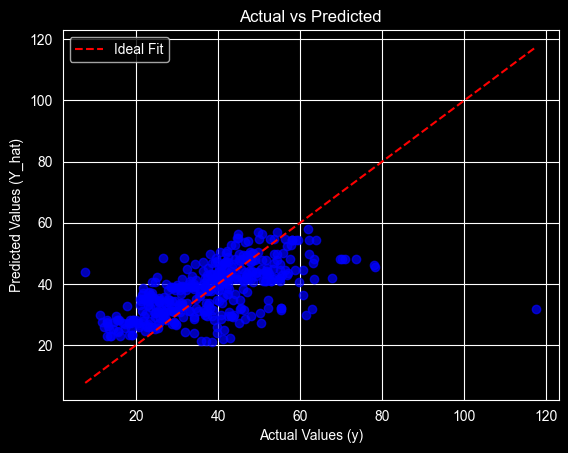

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# Both y and Y_hat_original must have shape (m,)
plt.scatter(Y, Y_hat_orignal, c="b", alpha=0.7)

# Draw a reference ideal line (y = x)
min_val = min(np.min(Y), np.min(Y_hat_orignal))
max_val = max(np.max(Y), np.max(Y_hat_orignal))
plt.plot([min_val, max_val], [min_val, max_val], c="r", linestyle="--", label="Ideal Fit")

plt.xlabel("Actual Values (y)")
plt.ylabel("Predicted Values (Y_hat)")
plt.title("Actual vs Predicted")
plt.legend()
plt.show()